# Cocoa pulp well-mixed model sensitivity analysis

In this notebook, we perform a sensitivity analysis on the well-mixed model to ascertain which parameters cause the most variation
in model behaviour. We start by doing a global Morris screening and then use Sobol indices on a subset of parameters to further 
interrogate the system. The results of this analysis will inform which parameters to vary in the Bayesian inference and the priors we should use.

## Background

### Overview of system

### Mathematical model

### Sensitivity analysis

## Retrieving the model for simulations

### Setup

In [1]:
import json
import time

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from fermenting_cocoa.scripts import build_model_pH_citric
from fermenting_cocoa.scripts import run_model_pH_citric

In [42]:
plt.rcParams['text.usetex'] = True
trial = "initial"
res_dir = f"../../resources/{trial}/pH_T_O2_citric"

The below method is used to convert a nested .json file into an unnested dictionary.

In [5]:
def flatten_json(data):
    items = {}
    for k, v in data.items():
        if isinstance(v, dict):
            items.update(flatten_json(v))
        else:
            items[k] = v
    return items

In [6]:
param_file = open(f"{res_dir}/params.json")
params_json = json.load(param_file)
params = flatten_json(params_json)

In [7]:
initial_conditions = params_json["initial_conditions"]

These scales are roughly the maximum sizes for each species. The solver uses nondimensional quantities, as these are easier to use Bayesian inference with.

In [8]:
scales = params_json["scales"]
short_labels = ["Glc", "Fru", "Cit", "EtOH", "LA", "Ac", "Y", "LAB", "AAB", "O2", "T", "pH"]

# Scaling initial conditions
initial_conditions_nd = {k: initial_conditions[k] / scales[f"{k}_sc"]
                         for k in initial_conditions.keys()}

### Running the model

We are now ready to run the model (with some default parameter values).

Here, we build the Jacobian for the symbolic solver. This only needs to be done once.

In [9]:
t_end = 168 # 7 days = 168 hours
verbose = False
model = build_model_pH_citric(params)

2026-06-16 12:21:57,500 Starting build pipeline for fermenting_pulp (target=ctypes, sparse=False)...
2026-06-16 12:21:57,508 Computing base symbolic Jacobians...
2026-06-16 12:21:58,705 Building large global Jacobians...
2026-06-16 12:21:58,713 Converting Jacobians to target format (Sparse: False)
2026-06-16 12:21:58,715 Extracting UZ Jacobians...
2026-06-16 12:21:58,735 Translating symbolic equations to C strings...
2026-06-16 12:22:01,029 End translating symbolic equations to C strings.
2026-06-16 12:22:01,030 [ctypes] Generating C code for system: fermenting_pulp
2026-06-16 12:22:01,050 [ctypes] Invoking compiler for Linux (backend: dense) from: /home/mghosh000/fermenting-cocoa/FermentingCocoa/fermenting_cocoa/scripts/sensitivity_analysis
2026-06-16 12:22:01,051 [ctypes] Command: gcc -O3 -shared -fPIC -I"/home/mghosh000/degrading-spacer/DegradingSpacer/venv/lib/python3.10/site-packages/pydae/daesolver" "/home/mghosh000/degrading-spacer/DegradingSpacer/venv/lib/python3.10/site-packag

In [10]:
model = run_model_pH_citric(model, params, initial_conditions_nd, t_end)

Next, we plot the results of this default model to see how each species behaves.

In [11]:
labels = ['Glucose', 'Fructose', 'Citric Acid', 'Ethanol', 'Lactic Acid', 'Acetic Acid',
          'Yeast', 'LAB', 'AAB', 'O2', 'Temperature', 'pH']
colours = ['blue', 'orange', 'darkgoldenrod', 'green', 'red', 'purple',
          'brown', 'pink', 'gray', 'cyan', 'black', 'darkviolet']

In [12]:
times = np.linspace(0, t_end, t_end + 1)

Creating the ambient temperature profile

In [13]:
def ambient_T(_times: np.array, T_e_min: float, T_e_max: float):
    """Calculates the ambient temperature profile given minimum
    and maximum values.
    """
    T_e_range = T_e_max - T_e_min
    return T_e_range / 2 * np.cos(np.pi * _times / 12) + (params['T_e_max'] - T_e_range / 2)

In [14]:
T_e = ambient_T(times, params['T_e_min'], params['T_e_max'])

In [15]:
def extract_data_from_model(_times, _model, _short_labels, _scales):
    """Creates a pandas dataframe from the _model data.
    """
    # The below is a helper function for converting pydae's output (with lots of timesteps) into an hourly array
    q_hourly = lambda symbol: np.interp(_times, _model.Time, _model.get_values(symbol)) * _scales[f"{symbol}_sc"]
    df = pd.DataFrame(columns=_short_labels)
    for label in _short_labels:
        df[label] = q_hourly(label)
    return df

In [16]:
def plot_all_profiles(_times, _df, _colours, _short_labels, _labels, _scales, _T_e):
    """Plots the profiles for a given set of data and timepoints.
    """
    nrows, ncols = 4, 3
    fig, axs = plt.subplots(nrows, ncols, figsize=(10, 12), sharex=True)
    plt.subplots_adjust(wspace=0.4, hspace=0.4)
    for i in range(11):
        ax = axs[i//ncols, i%ncols]
        ax.set_title(_labels[i])
        ax.set_xlabel('Time [h]')
        ax.ticklabel_format(axis='y', style='sci', scilimits=(-2, 5))

        if labels[i] == 'Temperature':
            ax.plot(_times, _df[_short_labels[i]], color=_colours[i], label='Pulp')
            ax.set_ylabel('°C')
            ax.plot(_times, _T_e, color=_colours[i], label='Ambient', linestyle='dotted', lw=0.5)
            ax.legend()
        else:
            ax.plot(_times, _df[_short_labels[i]], color=_colours[i])
            ax.set_ylabel('mg g(pulp)\\textsuperscript{-1}')

    ax_pH = axs[nrows-1, ncols-1]
    ax_pH.plot(_times, _df["pH"], color=_colours[-1])
    ax_pH.set_title(labels[-1])
    ax_pH.set_xlabel('Time [h]')

In [17]:
default_params_df = extract_data_from_model(times, model, short_labels, scales)

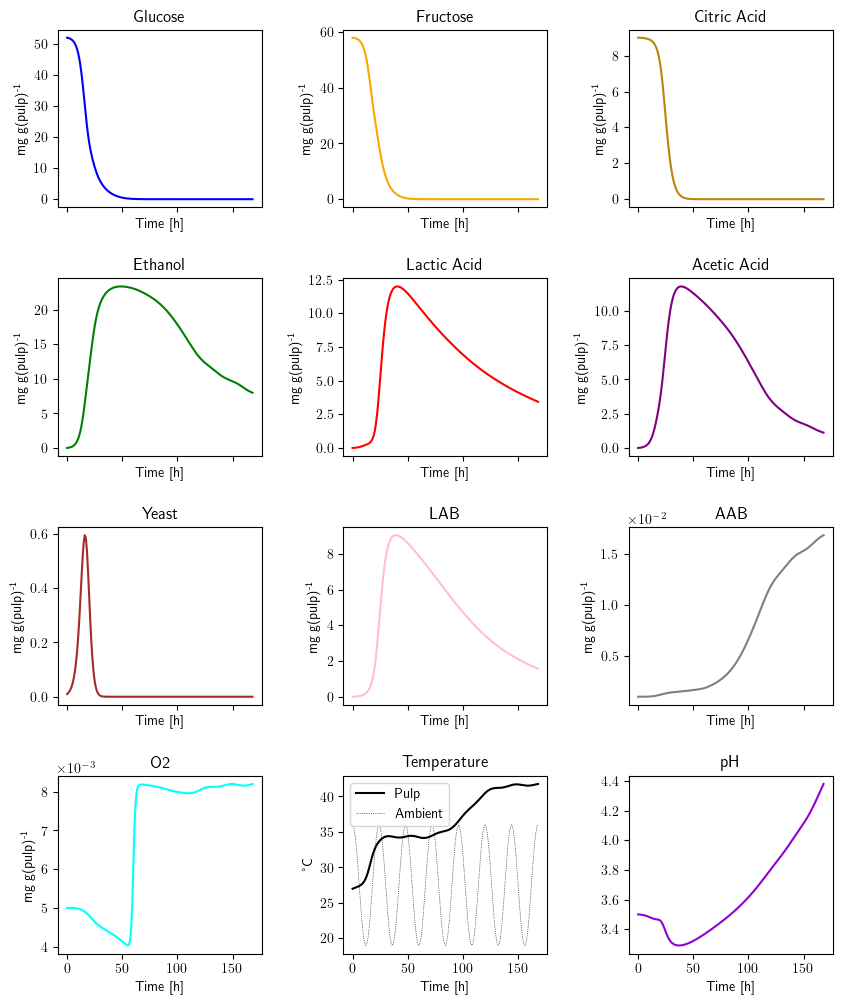

In [18]:
plot_all_profiles(times, default_params_df, colours, short_labels, labels, scales, T_e)

## Reading in/manufacturing data

### Manufacturing noisy data

We can use this to test how sensitive our model is to noisy data generated by default parameters. The advantage of this method is that we know the underlying parameters and so can judge the results based on this knowledge. We use the default parameters provided in `resources/initial/pH_T_O2_citric/params.json` to generate the noisy data (as demonstrated in the above plots).

We also assume that we don't have data for every hour, so plot sporadic datapoints.

In [19]:
n_time_rec = 30
times_rec = np.linspace(0, t_end, n_time_rec, dtype=int)

In [20]:
noise_scale = 0.01
std_devs = {short_label: scales[f"{short_label}_sc"] * noise_scale for short_label in short_labels}
noise = {short_label: np.random.normal(0, std_devs[short_label], n_time_rec) for short_label in short_labels}
noisy_df = pd.DataFrame(columns=short_labels)
for short_label in short_labels:
    noisy_df[short_label] = default_params_df[short_label].to_numpy()[times_rec] + noise[short_label]

We plot the noisy data below.

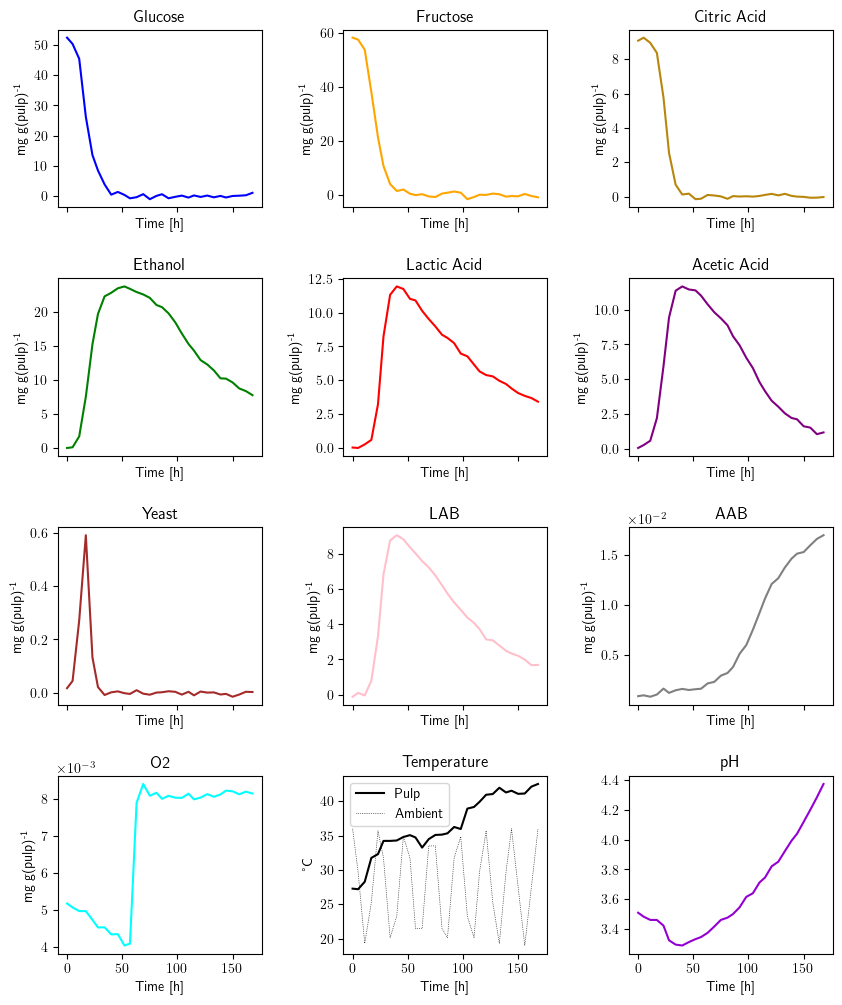

In [21]:
plot_all_profiles(times_rec, noisy_df, colours, short_labels, labels, scales, T_e[times_rec])

### Creating the problem and error measure

In [22]:
class Problem:
    """A class containing both the model and the recorded data.
    """

    def __init__(self, _model, _initial_conditions_nd, _t_end, _times_rec, _short_labels, _scales, _data_df, _param_info, _fixed_params):
        self._model = _model
        self._model_out = None
        self._initial_conditions_nd = _initial_conditions_nd
        self._t_end = _t_end
        self._times_rec = _times_rec
        self._short_labels = _short_labels
        self._scales = _scales
        self._data_df = _data_df
        self._param_info = _param_info # dict keyed by param name with value "lin" if not log-transformed and "log" if log-transformed
        self._fixed_params = _fixed_params # dict for all the fixed parameter values of the model

    def sse(self, _param_arr, Dt=1e-2):
        """Calculates the sum of squared errors between the model simulated with specific parameters and the recorded (or
        synthetic) data. The _param_arr argument is a numpy array of parameters in the same order as in the _param_info dict.
        Some parameters may be log-transformed so we must transform them back in the DAE system.
        """
        _names = list(self._param_info.keys())
        _var_params = {_names[i]: _param_arr[i] if self._param_info[_names[i]] == "lin" else 10 ** _param_arr[i]
                       for i in range(len(_param_arr))}
        _params = {**self._fixed_params, **_var_params}
        self._model_out = run_model_pH_citric(self._model, _params, self._initial_conditions_nd, self._t_end, Dt)
        _model_df = extract_data_from_model(self._times_rec, self._model_out, self._short_labels, self._scales)
        sse = 0
        for short_label in self._short_labels:
            scale = self._scales[f"{short_label}_sc"]
            sse += np.sum((_model_df[short_label] - self._data_df[short_label]) ** 2) / (scale ** 2)
        return sse

## Parameter selection

### Fixed vs. varying parameters

There are a few pre-processing steps required before we do Morris screening. Firstly, we need to specify which parameters are true physical constants and which we want to vary.

In [23]:
fixed_param_keys = ["T_min_Y", "T_opt_Y", "T_max_Y", "T_min_LAB", "T_opt_LAB", "T_max_LAB", "T_min_AAB", "T_opt_AAB", "T_max_AAB",
                    "T_e_min", "T_e_max", 
                    "C_air", 
                    "Delta_H_EtOH", "Delta_H_Ac", "R",
                    "M_EtOH", "M_LA", "M_Ac", "M_Cit",
                    "pH_initial", "K_w", "K_a1_Cit", "K_a2_Cit", "K_a3_Cit", "K_a_Ac", "K_a_LA", "Cat",
                    "pH_min_Y", "pH_opt_Y", "pH_max_Y", "pH_min_LAB", "pH_opt_LAB", "pH_max_LAB", "pH_min_AAB", "pH_opt_AAB", "pH_max_AAB",
                    "tau", "Glc", "Fru", "Cit", "EtOH", "LA", "Ac", "Y", "LAB", "AAB", "O2", "T", "pH", # initial conditions
                    "tau_sc", "Glc_sc", "Fru_sc", "Cit_sc", "EtOH_sc", "LA_sc", "Ac_sc", "Y_sc", "LAB_sc", "AAB_sc", "O2_sc", "T_sc", "pH_sc",
                    "alpha_solver"] # from pydae

Below we note the parameters that are being varied. We have $60$ parameters, which suggests that a Morris screening is a helpful step
to find the ranks of the various parameters in terms of how sensitive the model is to the parameter values.

In [24]:
fixed_params = {fixed_param: params[fixed_param] for fixed_param in fixed_param_keys}
var_params = {param: params[param] for param in params if param not in fixed_param_keys}
print(list(var_params.keys()), len(var_params))

['mu_max_Y_Glc', 'mu_max_Y_Fru', 'mu_max_Y_LA', 'mu_max_LAB_Glc', 'mu_max_LAB_Fru', 'mu_max_AAB_EtOH', 'mu_max_AAB_LA', 'mu_max_AAB_Ac', 'K_Glc_Y', 'K_Fru_Y', 'K_Glc_LAB', 'K_EtOH_AAB', 'K_LA_AAB', 'K_Fru_LAB', 'K_LA_Y', 'K_Ac_AAB', 'k_Y', 'k_LAB', 'k_AAB', 'Y_Glc_Y', 'Y_Glc_LAB', 'Y_Fru_Y', 'Y_EtOH_Y_Glc', 'Y_EtOH_Y_Fru', 'Y_EtOH_AAB', 'Y_LA_LAB_Glc', 'Y_LA_AAB', 'Y_Ac_LAB_Glc', 'Y_Ac_AAB_EtOH', 'Y_Ac_AAB_LA', 'Y_Fru_LAB', 'Y_EtOH_LAB_Glc', 'Y_EtOH_LAB_Fru', 'Y_EtOH_Y_LA', 'Y_LA_LAB_Fru', 'Y_LA_Y', 'Y_Ac_LAB_Fru', 'Y_Ac_Y_Glc', 'Y_Ac_Y_Fru', 'Y_Ac_AAB', 'Q_L', 'Y_Q_Glc', 'Y_Q_Fru', 'Y_Q_EtOH', 'Y_Q_LA', 'K_O2_EtOH', 'K_O2_LA', 'K_O2_Ac', 'A_max', 't_aer', 'b_LA', 'b_E0', 'b_E1', 'b_AC0', 'b_AC1', 'mu_max_LAB_Cit', 'K_Cit_LAB', 'Y_Cit_LAB', 'Y_LA_LAB_Cit', 'Y_Ac_LAB_Cit'] 60


We log-transform all parameter values, since we wish to sample from parameter distributions on a magnitude scale rather than a linear scale.

In [25]:
param_info = {param_name: "log" for param_name in var_params}
problem = Problem(model, initial_conditions_nd, t_end, times_rec, short_labels, scales, noisy_df, param_info, fixed_params)
log_var_params = {param: np.log10(params[param]) for param in var_params}
print(log_var_params)
param_arr = np.array(list(log_var_params.values()))
print(problem.sse(param_arr))

{'mu_max_Y_Glc': -0.39147396642280585, 'mu_max_Y_Fru': -0.632644078973981, 'mu_max_Y_LA': -0.3010299956639812, 'mu_max_LAB_Glc': -0.8632794328435931, 'mu_max_LAB_Fru': -0.7144426909922262, 'mu_max_AAB_EtOH': -0.3316140833099998, 'mu_max_AAB_LA': -1.7958800173440752, 'mu_max_AAB_Ac': -0.3010299956639812, 'K_Glc_Y': 1.586238378816471, 'K_Fru_Y': 1.6009946642881363, 'K_Glc_LAB': 1.5348634105484151, 'K_EtOH_AAB': 1.2039842444201259, 'K_LA_AAB': 3.409679570060356, 'K_Fru_LAB': 1.5864297599664114, 'K_LA_Y': 1.1684974835230326, 'K_Ac_AAB': 0.5843312243675307, 'k_Y': -1.3419886033428876, 'k_LAB': -2.154901959985743, 'k_AAB': -3.0177287669604316, 'Y_Glc_Y': 1.5225094379928779, 'Y_Glc_LAB': 1.6666209260963212, 'Y_Fru_Y': 1.5924987489987794, 'Y_EtOH_Y_Glc': 0.6269559514354474, 'Y_EtOH_Y_Fru': 0.7867514221455612, 'Y_EtOH_AAB': 3.2478878712550623, 'Y_LA_LAB_Glc': 0.95525468282018, 'Y_LA_AAB': 3.3037673944781614, 'Y_Ac_LAB_Glc': 0.5154764413823758, 'Y_Ac_AAB_EtOH': 1.8348528754731213, 'Y_Ac_AAB_LA':

Now, we select the bounds on each of the log-parameters. This step is subject to change and will likely influence the results of the Morris screening, so must be done carefully. Many of these bounds are based on the posterior distributions listed in the supplementary material of $^{[1]}$ or reported values if known (in their supplementary material).

In [138]:
bounds = {"mu_max_Y_Glc": [-1, -0.1], "mu_max_Y_Fru": [-2, -0.1], "mu_max_Y_LA": [-2, -0.1], "mu_max_LAB_Glc": [-3, -0.5],
          "mu_max_LAB_Fru": [-2, -0.4], "mu_max_AAB_EtOH": [-1, -0.1], "mu_max_AAB_LA": [-3, -1.2], "mu_max_AAB_Ac": [-3, -0.2],
          "K_Glc_Y": [-4, 1.9], "K_Fru_Y": [0.9, 2.1], "K_LA_Y": [0.5, 1.9], "K_Glc_LAB": [-0.5, 2.1], "K_Fru_LAB": [0.8, 1.9],
          "K_EtOH_AAB": [0.6, 1.5], "K_LA_AAB": [2, 3.7], "K_Ac_AAB": [-1, 1.4],
          "k_Y": [-1.8, -1.2], "k_LAB": [-2.6, -1.8], "k_AAB": [-3.5, -1.7],
          "Y_Glc_Y": [1, 1.9], "Y_Glc_LAB": [0.5, 1.9], "Y_Fru_Y": [1, 1.9], "Y_Fru_LAB": [1, 2], "Y_EtOH_Y_Glc": [-0.5, 1.3], "Y_EtOH_Y_Fru": [-0.5, 1.2],
          "Y_EtOH_LAB_Glc": [0, 1.4], "Y_EtOH_LAB_Fru": [-0.5, 1.4], "Y_EtOH_AAB": [2, 3.5], "Y_LA_LAB_Glc": [0, 1.2], "Y_LA_LAB_Fru": [0.2, 1.2],
          "Y_LA_AAB": [0, 3.7], "Y_Ac_LAB_Glc": [-0.5, 0.6], "Y_Ac_LAB_Fru": [-0.5, 1], "Y_EtOH_Y_LA": [-0.5, 1.3], "Y_Ac_AAB_EtOH": [1, 2.4],
          "Y_Ac_AAB_LA": [2, 3.5], "Y_Ac_Y_Glc": [-0.5, 0.3], "Y_Ac_Y_Fru": [-0.5, 0.4], "Y_LA_Y": [0, 1], "Y_Ac_AAB": [2, 3.5],
          # Below here are new parameters. Therefore, the bounds are more educated guesses
          "Q_L": [-4, 0], "Y_Q_Glc": [-2, 0], "Y_Q_Fru": [-2, 0], "Y_Q_EtOH": [-1, 1], "Y_Q_LA": [-2, 0],
          "K_O2_EtOH": [-4, -2.1], "K_O2_LA": [-4, -2.1], "K_O2_Ac": [-4, -2.1], "A_max": [-1, 1], "t_aer": [1.4, 1.9],
          "b_LA": [-3, -1], "b_E0": [-4, -2], "b_E1": [0, 2], "b_AC0": [-4, -2], "b_AC1": [0, 2],
          "mu_max_LAB_Cit": [-2, -0.1], "K_Cit_LAB": [0.3, 0.9], "Y_Cit_LAB": [0, 1.9], "Y_LA_LAB_Cit": [0, 1.2], "Y_Ac_LAB_Cit": [-0.5, 0.8]}

## Morris screening

### Setup

We are now ready to perform Morris screening. We make use of the SALib library to sample trajectories and carry out the screening.

In [139]:
meta_info = {
    "num_vars": 60,
    "names": list(param_info.keys()),
    "bounds": [bound_list for bound_list in bounds.values()]
}

In [70]:
from SALib.sample.morris import sample
from SALib.analyze.morris import analyze

In [144]:
n_morris = 8
param_values_all = []
for j in range(n_morris):
    param_values = sample(meta_info, N=100, num_levels=6, local_optimization=True)
    param_values_all.append(param_values)

### Parameter sweep and Morris screening

Below we carry out the parameter sweep. This involves simulating across many parameter sets, some of which may cause errors at the given timestep resolution. However, we don't want to increase resolution for all simulations as this would dramatically increase computational time. Hence, if an error arises, we catch it and re-run that simulation only with a smaller timestep (here we use `Dt = 1e-3`). We also run the Morris screening a number of times to see if the results are stable (i.e. if the rankings are similar between runs).

In [141]:
Y_all = []

In [146]:
# Do this n_morris times and compare results to see if they are relatively stable or not
start = time.time()
for j in range(n_morris):
    param_values = param_values_all[j]
    n_its = len(param_values)
    Y_list = []
    for i in range(n_its):
        if i % 100 == 0:
            print(f"Run {j} It {i}: {time.time() - start}")
        try:
            Y_list.append(problem.sse(param_values[i]))
        except RuntimeError:
            print(f"Convergence error at It {i}, increasing resolution...")
            Y_list.append(problem.sse(param_values[i], Dt=1e-3))
    
    Y = np.array(Y_list)
    Y_all.append(Y)

Run 4 It 0: 0.0002574920654296875
Run 4 It 100: 6.371559381484985
Run 4 It 200: 18.222820520401
Convergence error at It 256, increasing resolution...


/home/mghosh000/degrading-spacer/DegradingSpacer/venv/lib/python3.10/site-packages/pydae/core/model/ctypes_model.py:473: RuntimeWarning: Storage buffer size (10050) may be exceeded. Requested: 16802. PAD=50 shield may absorb overflow.
  warnings.warn(


Convergence error at It 257, increasing resolution...


/home/mghosh000/degrading-spacer/DegradingSpacer/venv/lib/python3.10/site-packages/pydae/core/model/ctypes_model.py:473: RuntimeWarning: Storage buffer size (10050) may be exceeded. Requested: 16802. PAD=50 shield may absorb overflow.
  warnings.warn(


Convergence error at It 258, increasing resolution...


...

Convergence error at It 2255, increasing resolution...


/home/mghosh000/degrading-spacer/DegradingSpacer/venv/lib/python3.10/site-packages/pydae/core/model/ctypes_model.py:473: RuntimeWarning: Storage buffer size (10050) may be exceeded. Requested: 16802. PAD=50 shield may absorb overflow.
  warnings.warn(


Convergence error at It 2256, increasing resolution...


/home/mghosh000/degrading-spacer/DegradingSpacer/venv/lib/python3.10/site-packages/pydae/core/model/ctypes_model.py:473: RuntimeWarning: Storage buffer size (10050) may be exceeded. Requested: 16802. PAD=50 shield may absorb overflow.
  warnings.warn(


Run 7 It 2300: 222.16065096855164
Run 7 It 2400: 231.18360018730164
Run 7 It 2500: 239.33057403564453
Run 7 It 2600: 249.94133830070496
Run 7 It 2700: 260.50140619277954
Run 7 It 2800: 270.7248754501343
Run 7 It 2900: 279.13731956481934
Run 7 It 3000: 287.5838475227356
Run 7 It 3100: 299.04007959365845
Run 7 It 3200: 308.7315721511841
Run 7 It 3300: 318.5606276988983
Run 7 It 3400: 327.62028551101685
Run 7 It 3500: 337.3149461746216
Run 7 It 3600: 344.73296451568604
Run 7 It 3700: 352.45311164855957
Run 7 It 3800: 360.16556692123413
Run 7 It 3900: 369.5371060371399
Run 7 It 4000: 377.6498637199402
Run 7 It 4100: 386.34552216529846
Run 7 It 4200: 396.2846591472626
Run 7 It 4300: 404.8892593383789
Run 7 It 4400: 413.90010952949524
Run 7 It 4500: 422.1462860107422
Run 7 It 4600: 433.09353613853455
Run 7 It 4700: 444.16442465782166
Run 7 It 4800: 454.3063094615936
Run 7 It 4900: 464.06249713897705
Run 7 It 5000: 471.94755840301514
Run 7 It 5100: 479.6909670829773
Run 7 It 5200: 487.9044902

Now we perform the analysis.

In [160]:
Si_list = []
for j in range(n_morris):
    Y = Y_all[j]
    param_values = param_values_all[j]
    Si = analyze(meta_info, param_values, Y, conf_level=0.95, print_to_console=False)
    Si_list.append(Si)

In Morris Global Sensitivity Analysis screening, the two main outputs are $\mu^{*}$ (`mu_star`) and $\sigma$ (`sigma`). $\mu^{*}$ measures the mean of absolute effects (i.e. the overall importance of a parameter across its given range). $\sigma$ is a little more complex but measures how much a given parameter is affected by (or affects) other parameters of the system. For instance, if a parameter is not tied to any others, it will give a low $\sigma$ value. If it has a large effect on others, its $\sigma$ value will be high.

In [161]:
sort_dict = lambda _dict: {k: v for k, v in sorted(_dict.items(), key=lambda item: item[1], reverse=True)}

Below we print the results and save them to a `.csv` file. We will take the top `k` parameters through to the Sobol indices analysis (which is more computationally expensive) based on the `mu_star` and `sigma` rankings. Here, `k` should be between `10` and `20`.

In [162]:
morris_df_all = pd.DataFrame(columns=["name"] + [f"mu_star_{j}" for j in range(n_morris)] + [f"sigma_{j}" for j in range(n_morris)])

In [163]:
for j in range(n_morris):
    Si = Si_list[j]
    mu_star, sigma = Si["mu_star"], Si["sigma"]
    mu_star_dict = {meta_info["names"][i]: mu_star[i] for i in range(len(mu_star))}
    sigma_dict = {meta_info["names"][i]: sigma[i] for i in range(len(sigma))}

    mu_star_sorted = sort_dict(mu_star_dict)
    sigma_sorted = sort_dict(sigma_dict)
    labels = list(mu_star_sorted.keys())
    if j == 0:
        morris_df_all["name"] = labels
    print("mu_star")
    mu_star_ranking = [0] * len(labels)
    for i in range(len(mu_star_sorted)):
        label = list(mu_star_sorted.keys())[i]
        label_pos = list(morris_df_all["name"]).index(label)
        mu_star_ranking[label_pos] = i + 1
        print(f"{i + 1}. {label}: {mu_star_sorted[label]}")
    print("-"*80)
    print("sigma")
    sigma_ranking = [0] * len(labels)
    for i in range(len(sigma_sorted)):
        label = list(sigma_sorted.keys())[i]
        label_pos = list(morris_df_all["name"]).index(label)
        sigma_ranking[label_pos] = i + 1
        print(f"{i + 1}. {label}: {sigma_sorted[label]}")

    sigma_sorted_by_mu_star = {label: sigma_sorted[label] for label in labels}
    morris_df = pd.DataFrame({"name": labels,
                              "mu_star": list(mu_star_sorted.values()),
                              "sigma": list(sigma_sorted_by_mu_star.values())})
    morris_df.to_csv(f"{res_dir}/morris/results_{j}.csv", index=False)
    morris_df_all[f"mu_star_{j}"] = mu_star_ranking
    morris_df_all[f"sigma_{j}"] = sigma_ranking
    print("="*80)
morris_df_all.to_csv(f"{res_dir}/morris/rankings.csv", index=False)

mu_star
1. Q_L: 17414.849377771305
2. t_aer: 15630.972138816964
3. A_max: 12054.757022406167
4. Y_EtOH_Y_Glc: 9802.914825543301
5. K_O2_EtOH: 9035.904556566175
6. Y_EtOH_AAB: 8388.061476952997
7. K_EtOH_AAB: 7528.319010478751
8. Y_Q_Glc: 7475.323542490226
9. mu_max_AAB_Ac: 5230.593697865457
10. mu_max_LAB_Cit: 5226.4193724212855
11. K_O2_Ac: 4133.138754905723
12. mu_max_LAB_Glc: 3703.843444462864
13. k_Y: 2821.83471174118
14. mu_max_Y_Glc: 2240.9053542043034
15. Y_Q_EtOH: 2204.7823467693433
16. mu_max_AAB_EtOH: 1755.8188216199765
17. K_Ac_AAB: 1636.0866727579448
18. b_E0: 1571.5268335185517
19. K_Glc_LAB: 1512.0209848224029
20. Y_Cit_LAB: 1486.5611829546076
21. Y_Fru_LAB: 979.0260575860343
22. Y_Ac_AAB_EtOH: 930.6444092946532
23. Y_Ac_AAB: 890.6426752783674
24. Y_Ac_LAB_Glc: 886.3503994472536
25. b_AC1: 728.0431230596256
26. K_Fru_Y: 524.3860234334624
27. mu_max_LAB_Fru: 421.1374771535456
28. Y_Ac_Y_Glc: 418.0292440897392
29. Y_Glc_Y: 389.9195203919038
30. K_Fru_LAB: 290.2397474459191


### Visualisation

We can also visualise these results using helper methods from `SALib`.

In [164]:
from SALib.plotting.morris import horizontal_bar_plot, covariance_plot

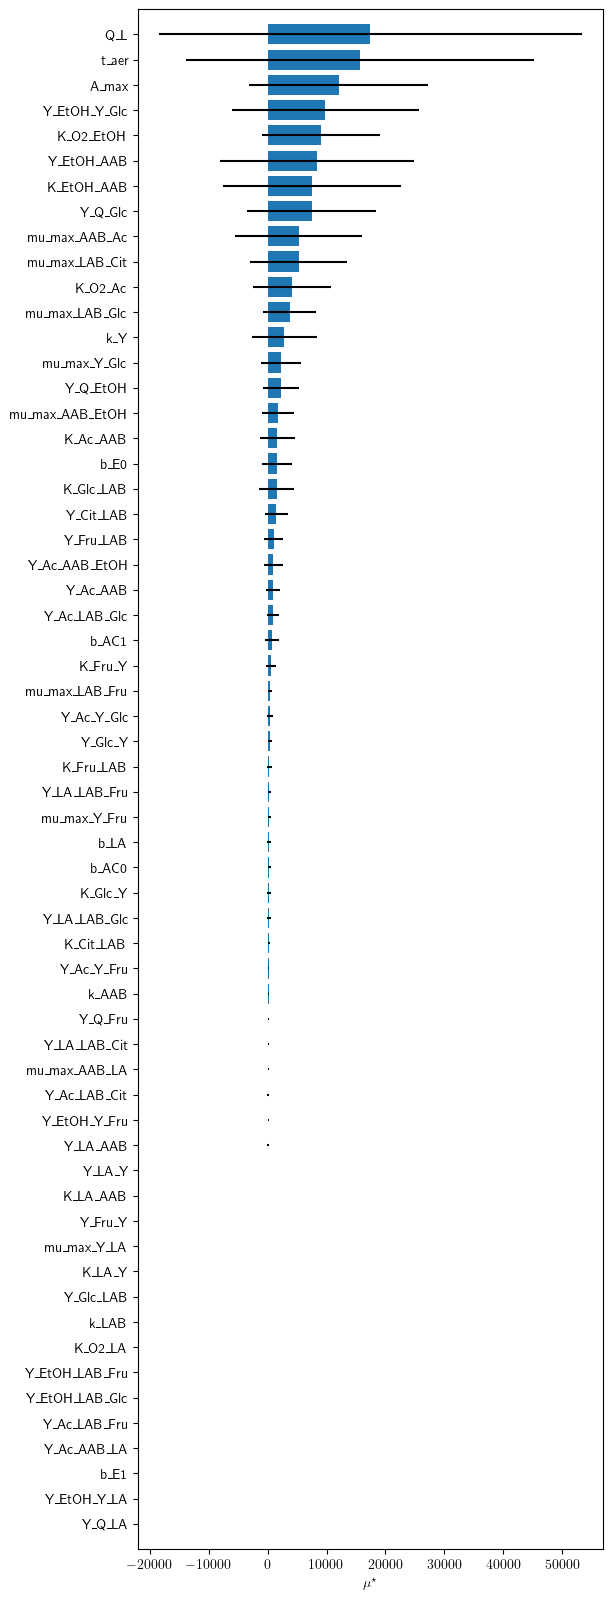

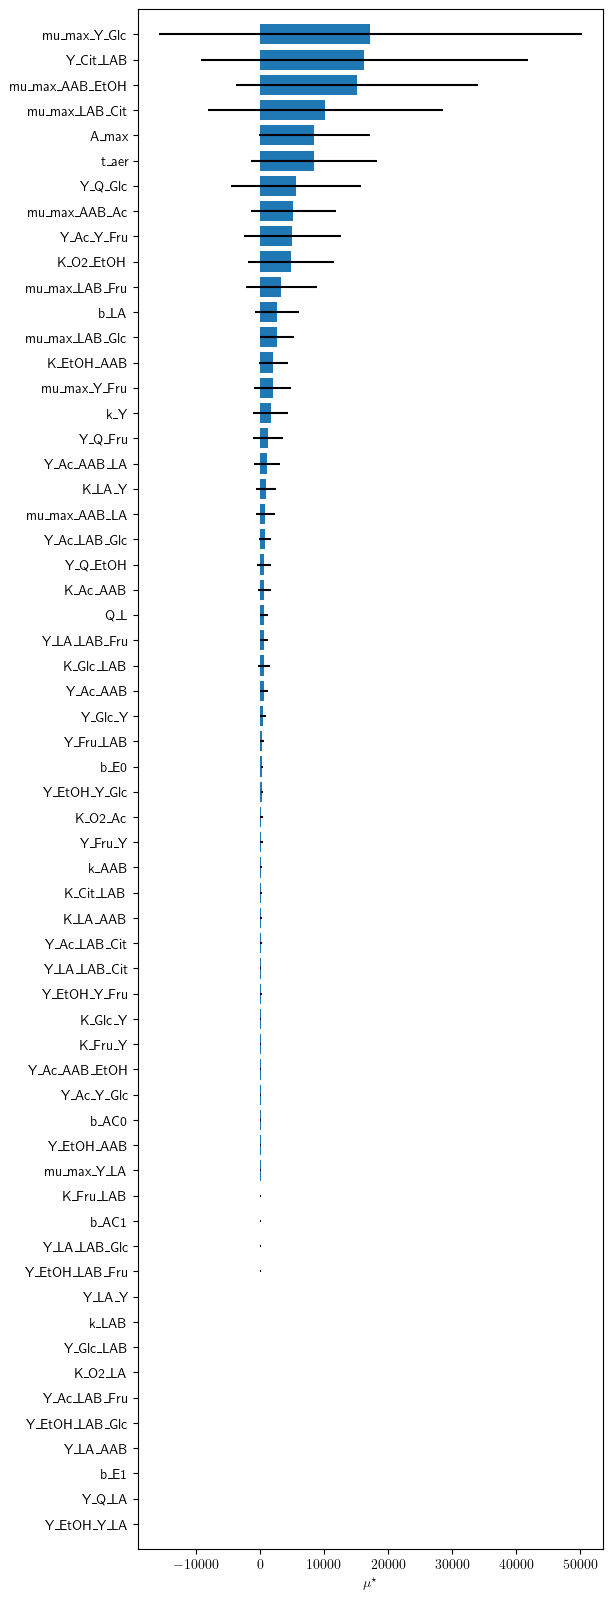

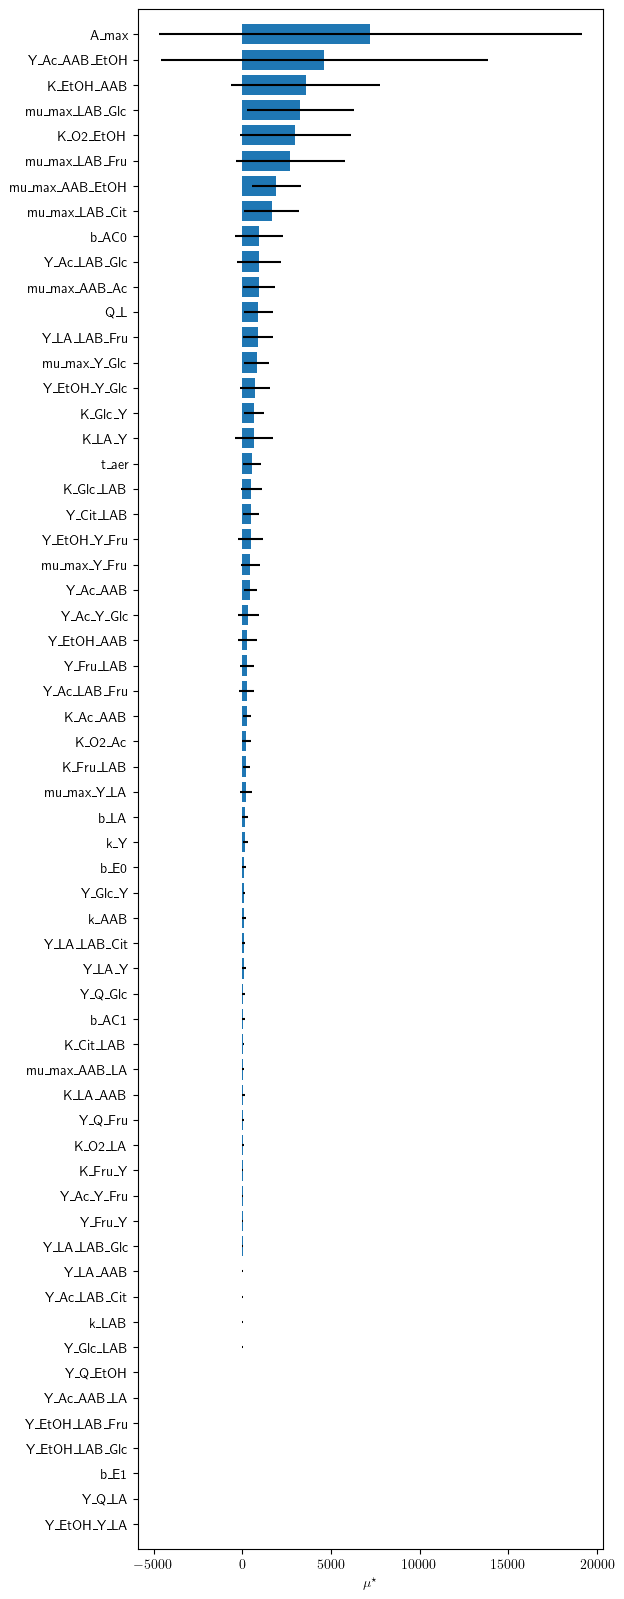

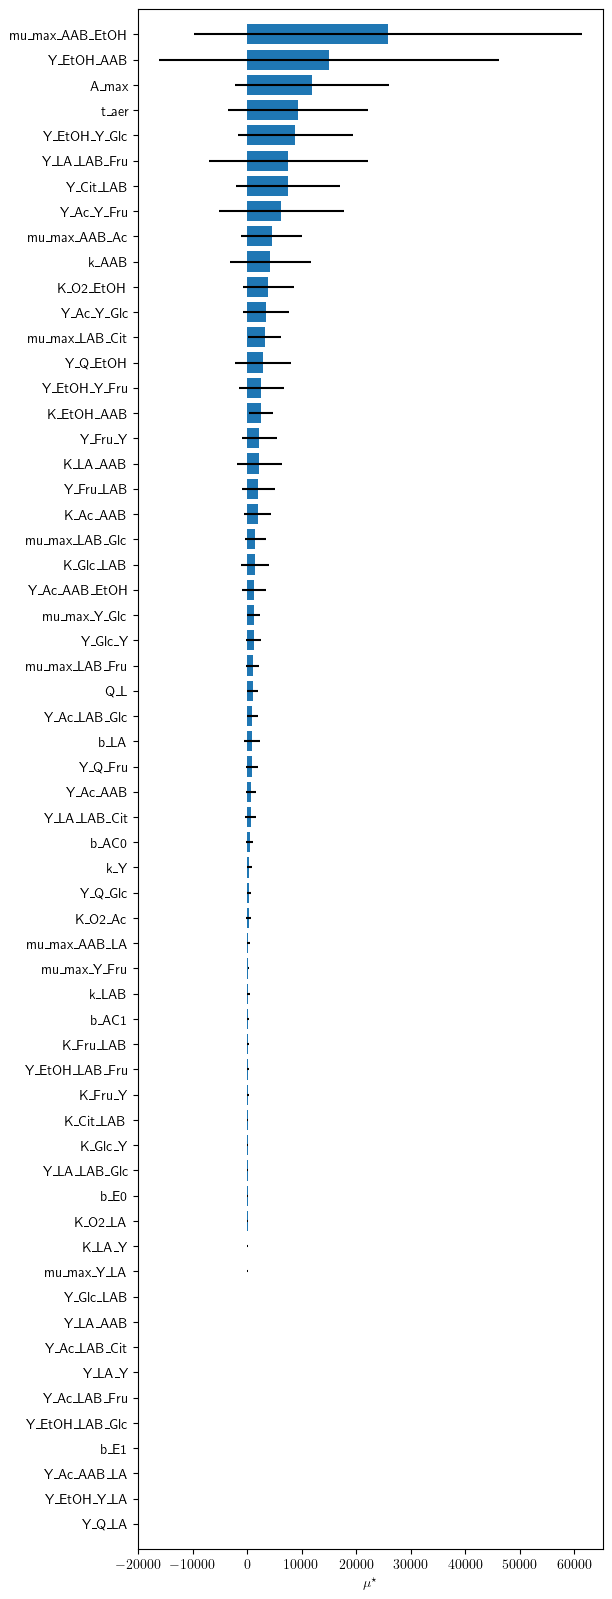

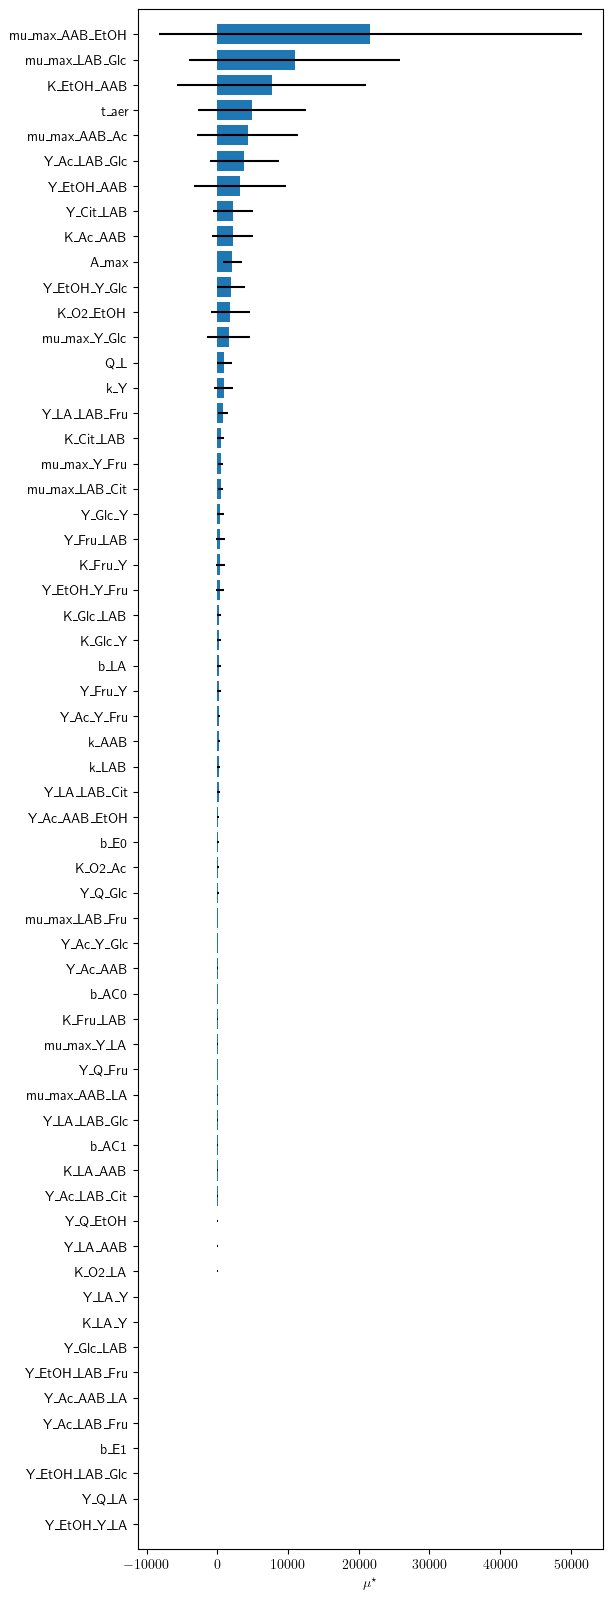

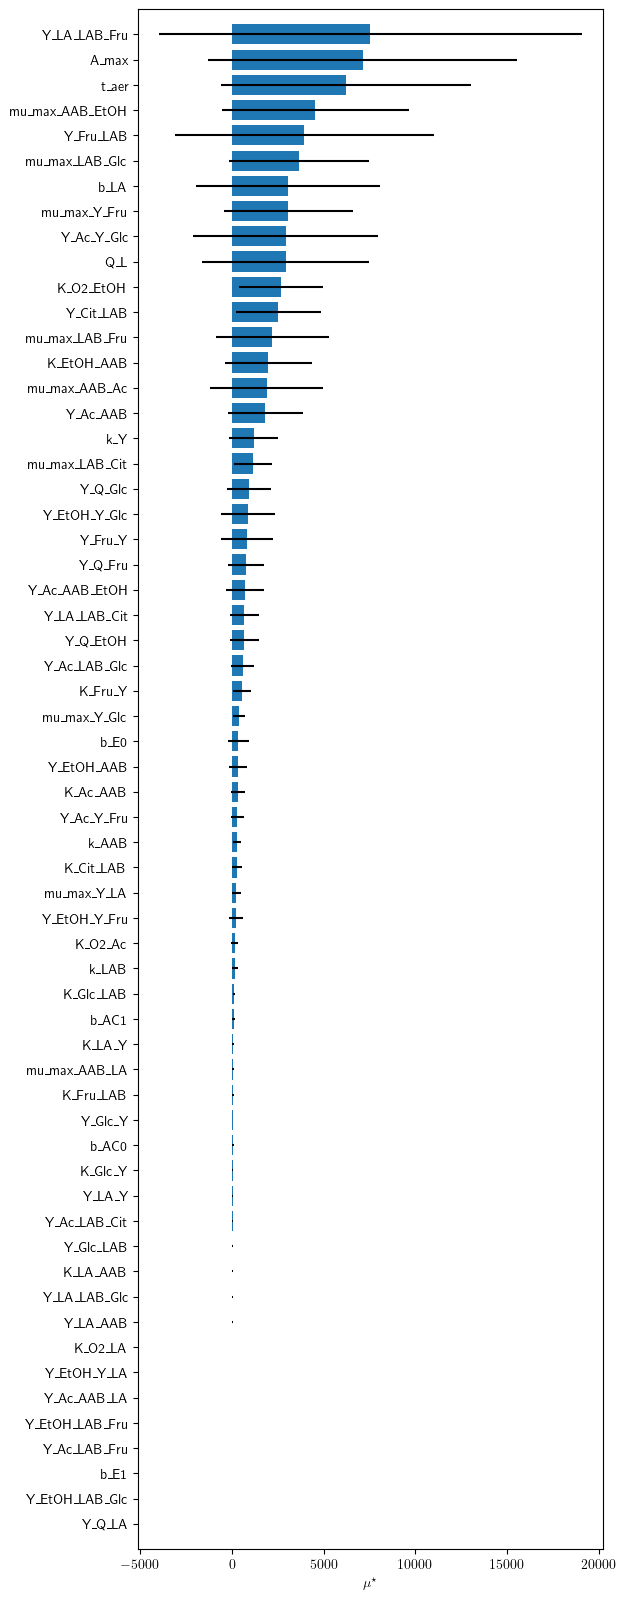

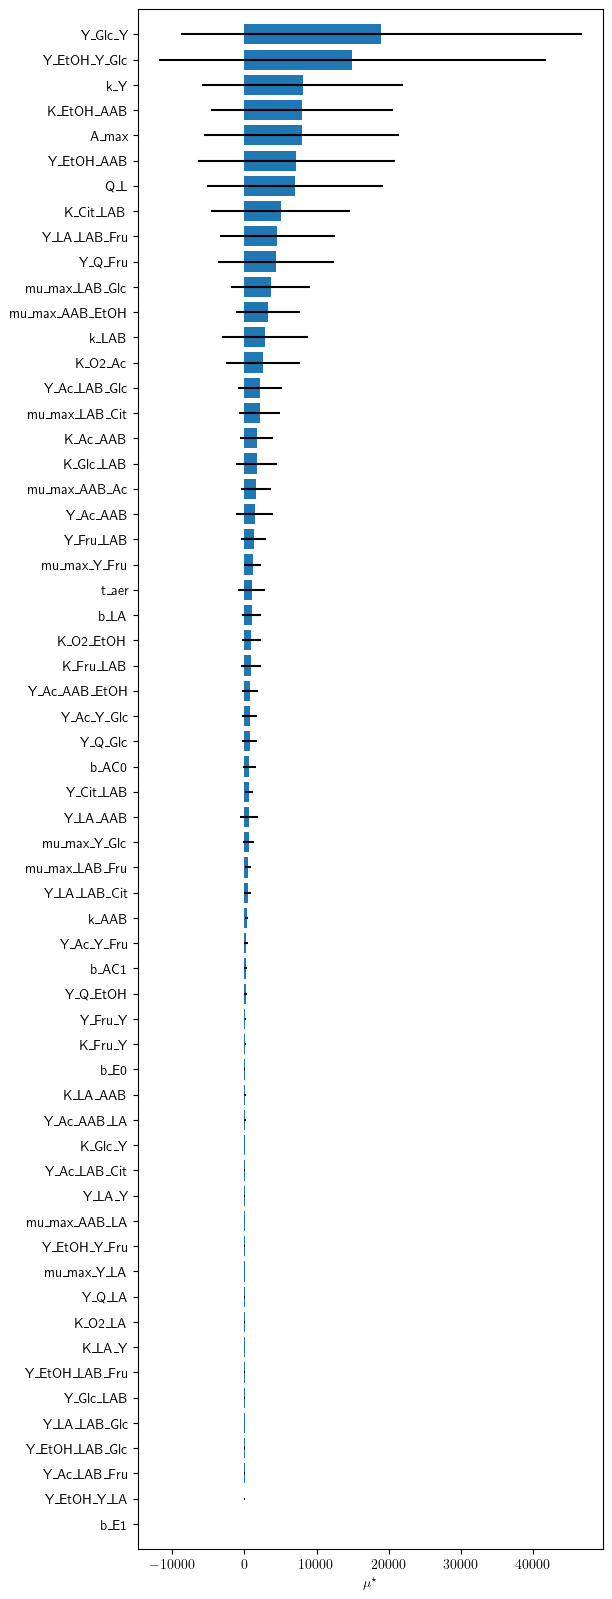

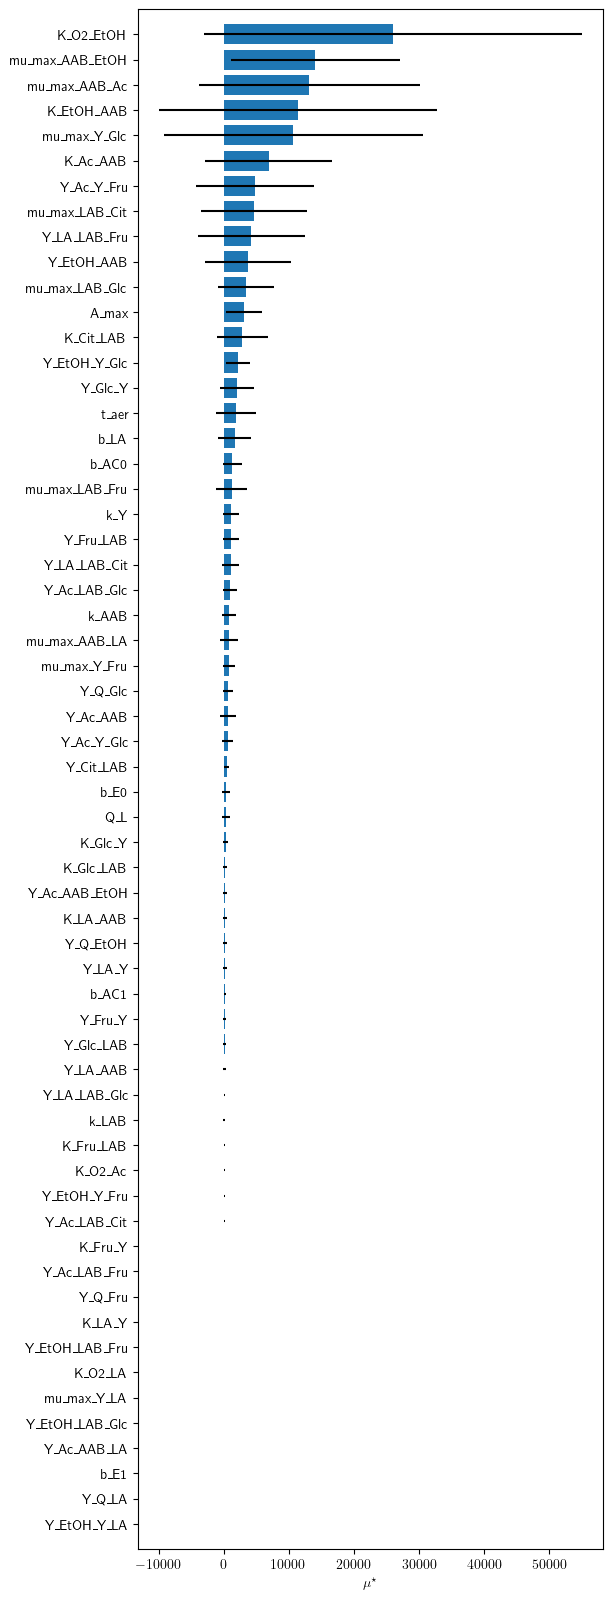

In [165]:
for j in range(n_morris):
    Si = Si_list[j]
    fig, ax = plt.subplots(1, 1, figsize=(6, 20))
    p = horizontal_bar_plot(ax, Si)
    # ax.set_xscale("log")
    fig.savefig(f"{res_dir}/morris/bar_{j}.png", dpi=400, bbox_inches="tight")

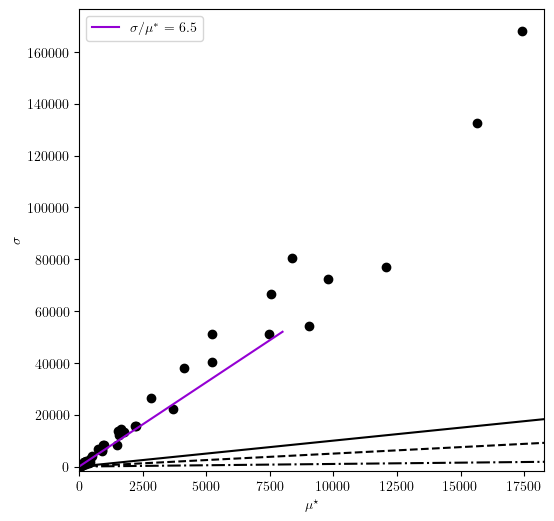

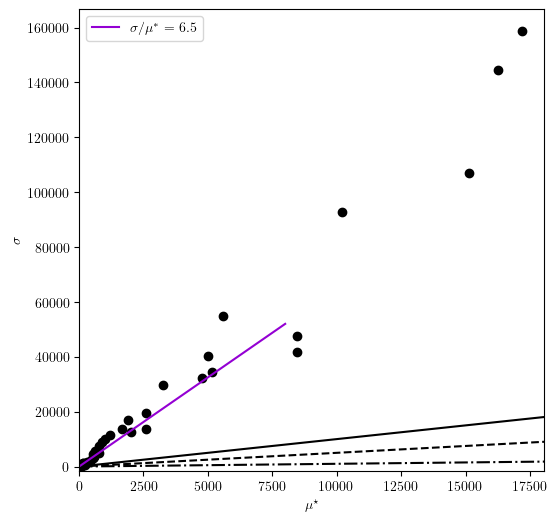

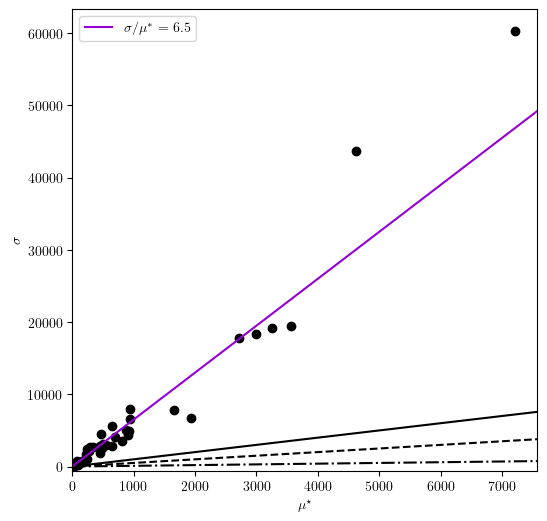

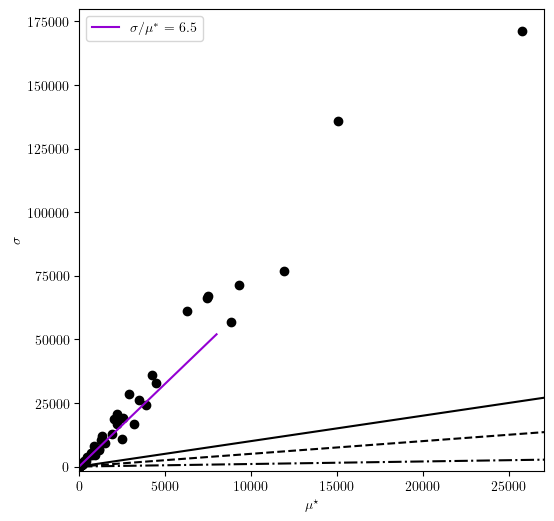

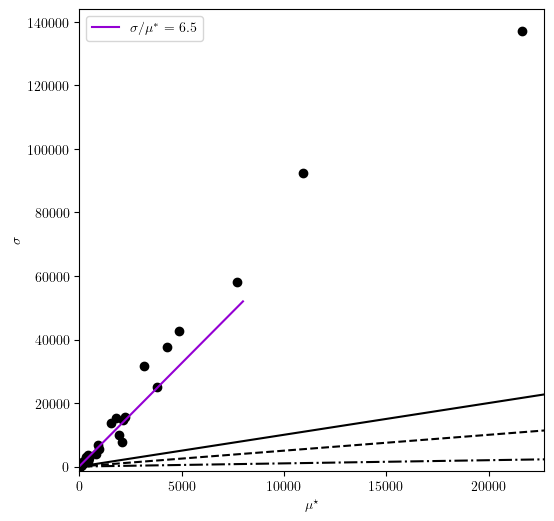

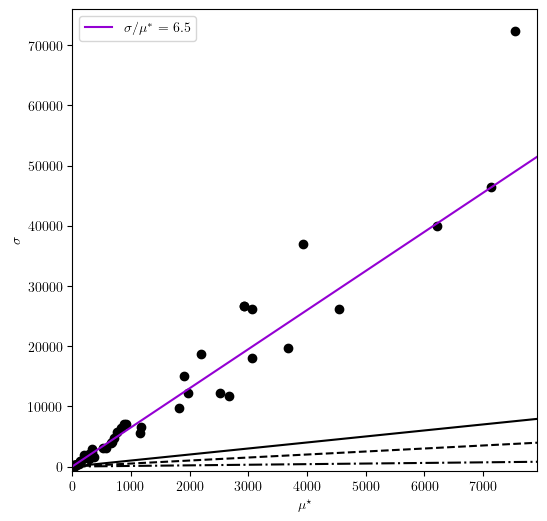

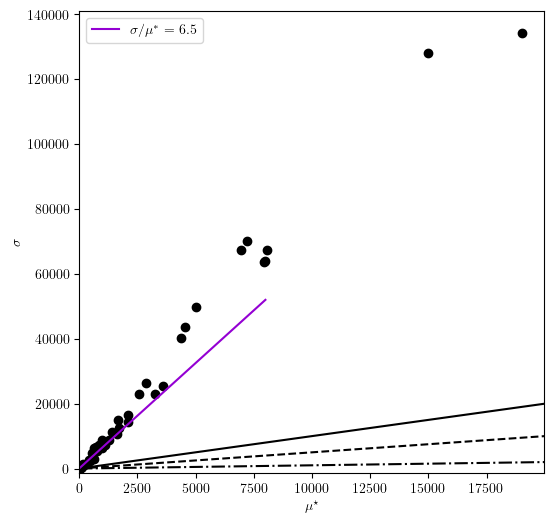

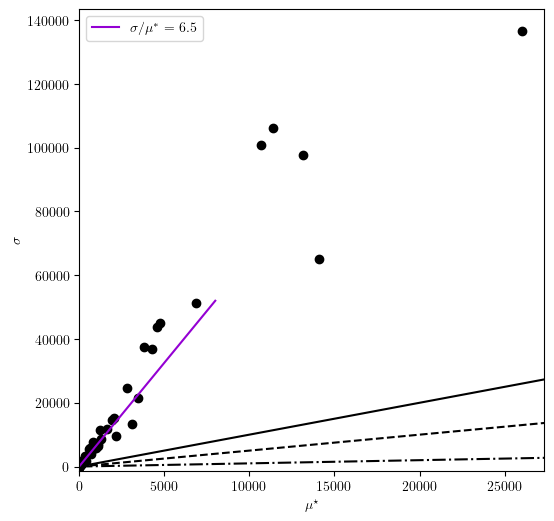

In [166]:
for j in range(n_morris):
    Si = Si_list[j]
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    p = covariance_plot(ax, Si)
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    mu_star = np.linspace(0, 8000, 10)
    gradient = 6.5
    sigma_obs = mu_star * gradient
    ax.plot(mu_star, sigma_obs, color="darkviolet", label=r"$\sigma / \mu^{*}=$" + f" ${gradient}$")
    ax.legend()
    fig.savefig(f"{res_dir}/morris/covariance_{j}.png", dpi=400, bbox_inches="tight")

### Progression to Sobol analysis

Now, given the results across multiple Morris screens, we determine which parameters appear most frequently in the top $k$ for $\mu^{*}$, where $k$ is the number of parameters we will use for Sobol, and push these forward.

In [167]:
k = 15

count = sum([(morris_df_all[f"mu_star_{j}"] <= k).astype(int)
             for j in range(n_morris)])
count_df = {list(morris_df_all["name"])[i]: list(count)[i] for i in range(len(count))}
count_df = sort_dict(count_df)
for i in range(len(count_df)):
    name = list(count_df.keys())[i]
    print(f"{i + 1}. {name}: {count_df[name]}")

1. A_max: 8
2. K_O2_EtOH: 7
3. K_EtOH_AAB: 7
4. mu_max_AAB_Ac: 7
5. mu_max_LAB_Glc: 7
6. mu_max_AAB_EtOH: 7
7. Y_EtOH_Y_Glc: 6
8. Q_L: 5
9. t_aer: 5
10. Y_EtOH_AAB: 5
11. mu_max_LAB_Cit: 5
12. mu_max_Y_Glc: 5
13. Y_LA_LAB_Fru: 5
14. Y_Cit_LAB: 4
15. k_Y: 3
16. Y_Ac_LAB_Glc: 3
17. mu_max_LAB_Fru: 3
18. Y_Ac_Y_Fru: 3
19. Y_Q_Glc: 2
20. K_O2_Ac: 2
21. Y_Q_EtOH: 2
22. K_Ac_AAB: 2
23. Y_Ac_Y_Glc: 2
24. Y_Glc_Y: 2
25. mu_max_Y_Fru: 2
26. b_LA: 2
27. K_Cit_LAB: 2
28. Y_Fru_LAB: 1
29. Y_Ac_AAB_EtOH: 1
30. b_AC0: 1
31. k_AAB: 1
32. Y_Q_Fru: 1
33. Y_EtOH_Y_Fru: 1
34. k_LAB: 1
35. b_E0: 0
36. K_Glc_LAB: 0
37. Y_Ac_AAB: 0
38. b_AC1: 0
39. K_Fru_Y: 0
40. K_Fru_LAB: 0
41. K_Glc_Y: 0
42. Y_LA_LAB_Glc: 0
43. Y_LA_LAB_Cit: 0
44. mu_max_AAB_LA: 0
45. Y_Ac_LAB_Cit: 0
46. Y_LA_AAB: 0
47. Y_LA_Y: 0
48. K_LA_AAB: 0
49. Y_Fru_Y: 0
50. mu_max_Y_LA: 0
51. K_LA_Y: 0
52. Y_Glc_LAB: 0
53. K_O2_LA: 0
54. Y_EtOH_LAB_Fru: 0
55. Y_EtOH_LAB_Glc: 0
56. Y_Ac_LAB_Fru: 0
57. Y_Ac_AAB_LA: 0
58. b_E1: 0
59. Y_EtOH_Y_LA: 0
6

## References

$[1]$: M. Moreno-Zambrano _et al._ (2022), Exploring cocoa bean fermentation mechanisms by kinetic modelling, _R Soc. Open Sci._ **9** (2), 210274.